In [1]:
import cv2
import numpy as np
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

## Setup

In [2]:
def imshow(img):
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")

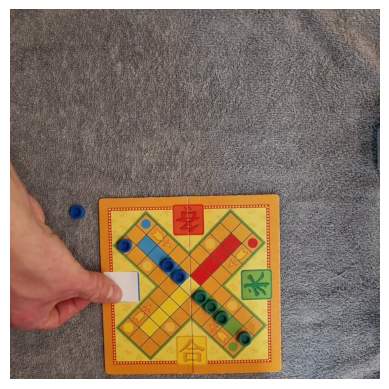

In [3]:
cap = cv2.VideoCapture("data/vid_3_dist=2.mp4")

frame_number = 2820  # the frame you want
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)

ret, frame = cap.read()  # read the frame
if not ret:
    cap.release()
    raise RuntimeError(f"Could not read frame {frame_number}")

cap.release()  # release after reading

# Convert BGR → RGB for display
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.imshow(frame_rgb)
plt.axis("off")
plt.show()

code below can be used to find HSV filters to find pawns on the frame

In [4]:
# img_hsv = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2HSV)
# def nothing(x):
#     pass

# cv2.namedWindow("mask")
# cv2.createTrackbar("H min", "mask", 0, 179, nothing)
# cv2.createTrackbar("H max", "mask", 179, 179, nothing)
# cv2.createTrackbar("S min", "mask", 0, 255, nothing)
# cv2.createTrackbar("S max", "mask", 255, 255, nothing)
# cv2.createTrackbar("V min", "mask", 0, 255, nothing)
# cv2.createTrackbar("V max", "mask", 255, 255, nothing)

# while True:
#     h_min = cv2.getTrackbarPos("H min", "mask")
#     h_max = cv2.getTrackbarPos("H max", "mask")
#     s_min = cv2.getTrackbarPos("S min", "mask")
#     s_max = cv2.getTrackbarPos("S max", "mask")
#     v_min = cv2.getTrackbarPos("V min", "mask")
#     v_max = cv2.getTrackbarPos("V max", "mask")

#     lower = np.array([h_min, s_min, v_min])
#     upper = np.array([h_max, s_max, v_max])
#     mask = cv2.inRange(img_hsv, lower, upper)

#     cv2.imshow("mask", mask)
#     if cv2.waitKey(1) & 0xFF == 27:  # ESC to exit
#         break

# cv2.destroyAllWindows()

## Create color based pawn mask

In [45]:
def find_green_pawns(frame_bgr):
    frame_hsv = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2HSV)

    lower_green = np.array([80, 100, 0])
    # upper_green = np.array([100, 255, 80])
    upper_green = np.array([95, 255, 160])

    green_mask = cv2.inRange(frame_hsv, lower_green, upper_green)

    kernel = np.ones((5, 5), np.uint8)

    green_open = cv2.morphologyEx(green_mask, cv2.MORPH_OPEN, kernel)
    green_closed = cv2.morphologyEx(green_open, cv2.MORPH_CLOSE, kernel)

    return green_mask


def find_blue_pawns(frame_bgr):
    frame_hsv = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2HSV)

    lower_blue = np.array([108, 100, 60])
    upper_blue = np.array([120, 255, 160])

    blue_mask = cv2.inRange(frame_hsv, lower_blue, upper_blue)

    kernel = np.ones((5, 5), np.uint8)

    blue_open = cv2.morphologyEx(blue_mask, cv2.MORPH_OPEN, kernel)
    blue_closed = cv2.morphologyEx(blue_open, cv2.MORPH_CLOSE, kernel)

    return blue_mask

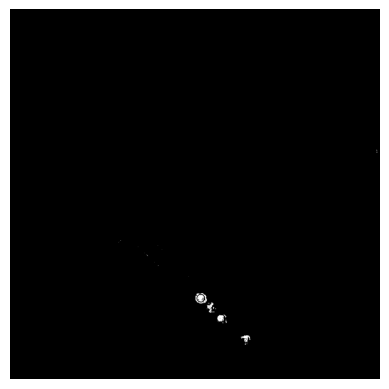

In [21]:
green_mask = find_green_pawns(frame)
imshow(green_mask)

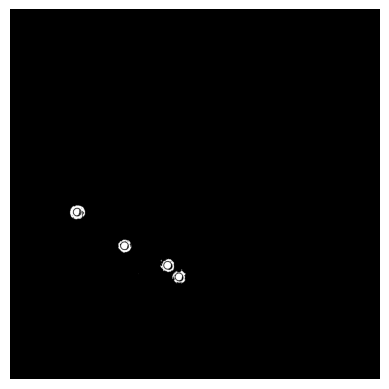

In [22]:
blue_mask = find_blue_pawns(frame)
imshow(blue_mask)

## Mark each pawn by finding connected components

In [23]:
def mark_pawns(mask, min_area=500):
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask)
    pawn_centers = []

    for i in range(1, num_labels):  # skip background
        x, y, w, h, area = stats[i]
        cx, cy = centroids[i]

        if area < min_area:
            continue

        pawn_centers.append((cx, cy))

    return pawn_centers

def draw_pawn_circles(frame, pawn_centers, color):
    frame = frame.copy()
    for cx, cy in pawn_centers:
        cv2.circle(frame, (int(cx), int(cy)), 15, color, 2)

    imshow(frame)
    return frame

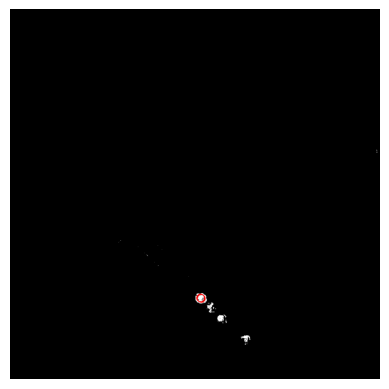

In [24]:
draw_pawn_circles(cv2.cvtColor(green_mask, cv2.COLOR_GRAY2BGR), mark_pawns(find_green_pawns(frame)), (0, 0, 255));

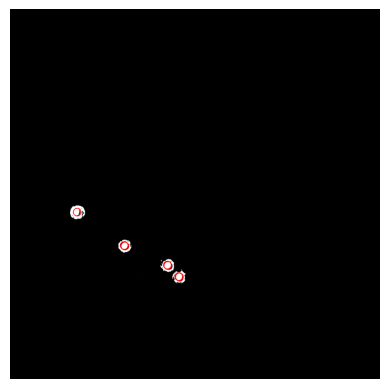

In [25]:
draw_pawn_circles(cv2.cvtColor(blue_mask, cv2.COLOR_GRAY2BGR), mark_pawns(find_blue_pawns(frame)), (0, 0, 255));

In [49]:
def find_green_pawns_alt(frame_bgr):
    frame_hsv = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2HSV)

    lower_green = np.array([80, 100, 0])
    upper_green = np.array([100, 255, 80])

    green_mask = cv2.inRange(frame_hsv, lower_green, upper_green)

    kernel = np.ones((5, 5), np.uint8)

    green_open = cv2.morphologyEx(green_mask, cv2.MORPH_OPEN, kernel)
    green_closed = cv2.morphologyEx(green_open, cv2.MORPH_CLOSE, kernel)

    return green_mask


def find_blue_pawns_alt(frame_bgr):
    frame_hsv = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2HSV)

    lower_blue = np.array([108, 100, 60])
    upper_blue = np.array([120, 255, 120])

    blue_mask = cv2.inRange(frame_hsv, lower_blue, upper_blue)

    kernel = np.ones((5, 5), np.uint8)

    blue_open = cv2.morphologyEx(blue_mask, cv2.MORPH_OPEN, kernel)
    blue_closed = cv2.morphologyEx(blue_open, cv2.MORPH_CLOSE, kernel)

    return blue_mask

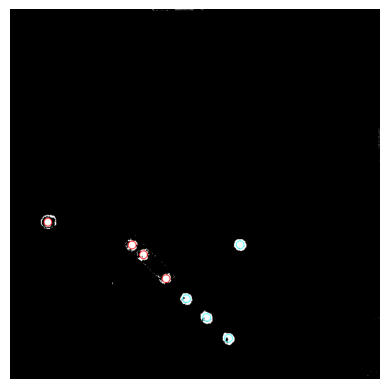

In [39]:
mask_green = find_green_pawns(frame)

# Mask that shows ONLY large components (>3000)
large_green_mask = np.zeros_like(mask_green)
final_green_mask = mask_green.copy()

# Connected components
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask_green)
pawn_centers_green = []

for i in range(1, num_labels):  # skip background
    x, y, w, h, area = stats[i]
    cx, cy = centroids[i]
    min_area = 500
    if area < min_area:
        continue

    if area > 3000:
        roi = frame[y:y+h, x:x+w]
        alt_mask = find_green_pawns_alt(roi)
        large_green_mask[y:y+h, x:x+w] += alt_mask
        final_green_mask[y:y+h, x:x+w] = alt_mask
        n2, _, stats2, centroids2 = cv2.connectedComponentsWithStats(alt_mask)
    
        for j in range(1, n2):
            a2 = stats2[j, cv2.CC_STAT_AREA]
            if a2 < min_area:
                continue
    
            cx2, cy2 = centroids2[j]
            pawn_centers_green.append((x + cx2, y + cy2))
    
        continue
        
    pawn_centers_green.append((cx, cy))

mask_blue = find_blue_pawns(frame)

# Mask that shows ONLY large components (>3000)
large_blue_mask = np.zeros_like(mask_blue)
final_blue_mask = mask_blue.copy()

# Connected components
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask_blue)
pawn_centers_blue = []

for i in range(1, num_labels):  # skip background
    x, y, w, h, area = stats[i]
    cx, cy = centroids[i]
    min_area = 500
    if area < min_area:
        continue

    if area > 3000:
        roi = frame[y:y+h, x:x+w]
        alt_mask = find_blue_pawns_alt(roi)
        large_blue_mask[y:y+h, x:x+w] += alt_mask
        final_blue_mask[y:y+h, x:x+w] = alt_mask
        n2, _, stats2, centroids2 = cv2.connectedComponentsWithStats(alt_mask)
    
        for j in range(1, n2):
            a2 = stats2[j, cv2.CC_STAT_AREA]
            if a2 < min_area:
                continue
    
            cx2, cy2 = centroids2[j]
            pawn_centers_blue.append((x + cx2, y + cy2))
    
        continue
        
    pawn_centers_blue.append((cx, cy))

# Draw detected pawns
# output_frame = frame
output_frame = cv2.cvtColor(mask_green+mask_blue, cv2.COLOR_GRAY2BGR)
for cx, cy in pawn_centers_green:
    cv2.circle(output_frame, (int(cx), int(cy)), 15, (255, 255, 51), 2)
    cv2.circle(frame, (int(cx), int(cy)), 15, (255, 255, 51), 2)
    
for cx, cy in pawn_centers_blue:
    cv2.circle(output_frame, (int(cx), int(cy)), 15, (0, 0, 255), 2)
    cv2.circle(frame, (int(cx), int(cy)), 15, (0, 0, 255), 2)

imshow(output_frame)

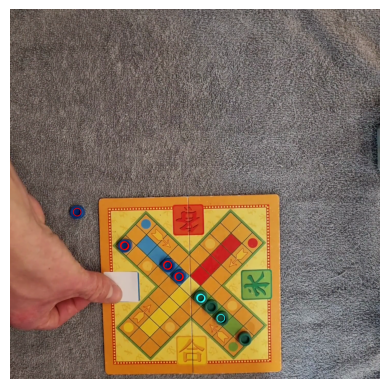

In [28]:
imshow(frame)

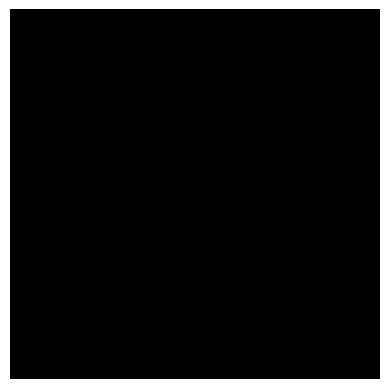

In [29]:
imshow(large_green_mask)

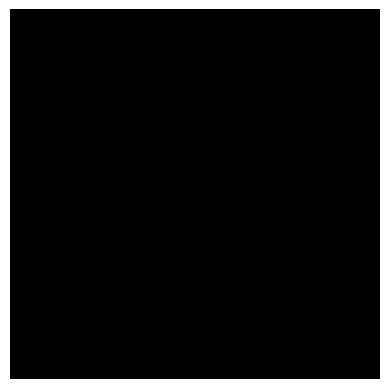

In [30]:
imshow(large_blue_mask)

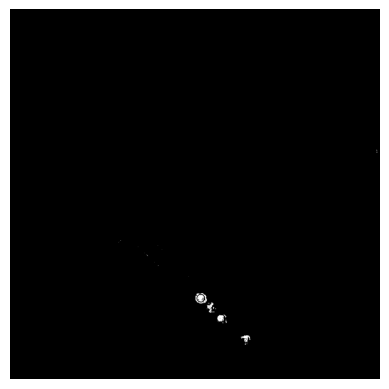

In [31]:
imshow(final_green_mask)

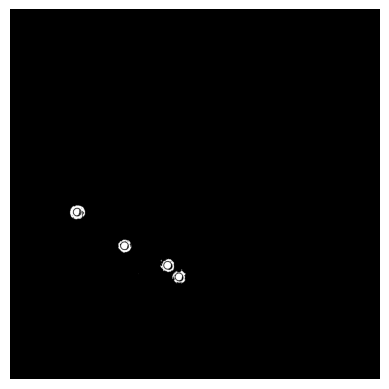

In [32]:
imshow(final_blue_mask)

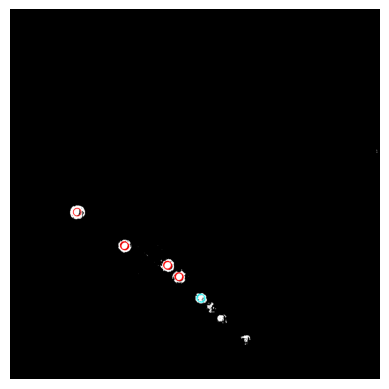

In [33]:
output_frame = cv2.cvtColor(final_green_mask+final_blue_mask, cv2.COLOR_GRAY2BGR)
for cx, cy in pawn_centers_green:
    cv2.circle(output_frame, (int(cx), int(cy)), 15, (255, 255, 51), 2)
    cv2.circle(frame, (int(cx), int(cy)), 15, (255, 255, 51), 2)
    
for cx, cy in pawn_centers_blue:
    cv2.circle(output_frame, (int(cx), int(cy)), 15, (0, 0, 255), 2)
    cv2.circle(frame, (int(cx), int(cy)), 15, (0, 0, 255), 2)

imshow(output_frame)

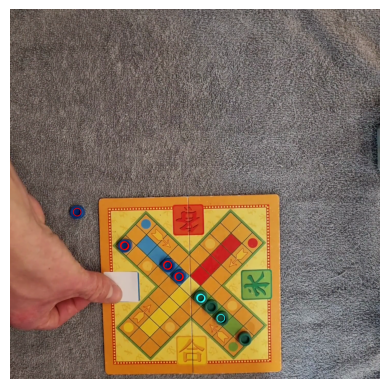

In [34]:
imshow(frame)

## Find pawns on the whole video

In [35]:
# cap = cv2.VideoCapture("data/vid_2_dist=1.mp4")

# # Video properties
# fps = cap.get(cv2.CAP_PROP_FPS)
# width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
# height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
# total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# green_4_count = 0
# blue_4_count = 0
# both_4_count = 0
# processed_frames = 0

# fourcc = cv2.VideoWriter_fourcc(*"mp4v")
# output_writer = cv2.VideoWriter("pawns_marked.mp4", fourcc, fps, (width, height))

# for _ in tqdm(range(total_frames), desc="Processing video"):
#     ret, frame = cap.read()
#     if not ret:
#         break
        
#     mask_green = find_green_pawns(frame)

#     # Connected components
#     num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask_green)
#     pawn_centers_green = []

#     for i in range(1, num_labels):  # skip background
#         x, y, w, h, area = stats[i]
#         cx, cy = centroids[i]
#         min_area = 500
#         if area < min_area:
#             continue
            
#         pawn_centers_green.append((cx, cy))

#     mask_blue = find_blue_pawns(frame)

#     # Connected components
#     num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask_blue)
#     pawn_centers_blue = []

#     for i in range(1, num_labels):  # skip background
#         x, y, w, h, area = stats[i]
#         cx, cy = centroids[i]
#         min_area = 500
#         if area < min_area:
#             continue
            
#         pawn_centers_blue.append((cx, cy))

#     # Draw detected pawns
#     output_frame = frame
#     # output_frame = cv2.cvtColor(mask_green+mask_blue, cv2.COLOR_GRAY2BGR)
#     for cx, cy in pawn_centers_green:
#         cv2.circle(output_frame, (int(cx), int(cy)), 15, (255, 255, 51), 2)
        
#     for cx, cy in pawn_centers_blue:
#         cv2.circle(output_frame, (int(cx), int(cy)), 15, (0, 0, 255), 2)

#     n_green = len(pawn_centers_green)
#     n_blue = len(pawn_centers_blue)
    
#     processed_frames += 1
    
#     if n_green == 4:
#         green_4_count += 1
    
#     if n_blue == 4:
#         blue_4_count += 1
    
#     if n_green == 4 and n_blue == 4:
#         both_4_count += 1

#     output_writer.write(output_frame)

# cap.release()
# output_writer.release()
# print("Finished writing video: pawns_marked.mp4")

In [36]:
# print("Finished writing video: pawns_marked.mp4")

# print(f"Total processed frames: {processed_frames}")
# print(f"Frames with 4 green pawns visible: {green_4_count}")
# print(f"Frames with 4 blue pawns visible: {blue_4_count}")
# print(f"Frames with 4 green AND 4 blue pawns visible: {both_4_count}")

# print("\nPercentages:")
# print(f"4 green visible: {100 * green_4_count / processed_frames:.2f}%")
# print(f"4 blue visible: {100 * blue_4_count / processed_frames:.2f}%")
# print(f"Both 4 visible: {100 * both_4_count / processed_frames:.2f}%")

In [50]:
vids = [
       "data/vid_1_dist=1.mp4", "data/vid_2_dist=1.mp4", "data/vid_3_dist=1.mp4",
       "data/vid_1_dist=2.mp4", "data/vid_2_dist=2.mp4", "data/vid_3_dist=2.mp4",
       "data/vid_1_dist=3.mp4", "data/vid_2_dist=3.mp4", "data/vid_3_dist=3.mp4",
]

for vid in vids:

    cap = cv2.VideoCapture(vid)
    
    # Video properties
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    green_4_count = 0
    blue_4_count = 0
    both_4_count = 0
    processed_frames = 0
    
    for _ in tqdm(range(total_frames), desc="Processing video"):
        ret, frame = cap.read()
        if not ret:
            break
            
        mask_green = find_green_pawns(frame)
    
        # Connected components
        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask_green)
        pawn_centers_green = []
    
        for i in range(1, num_labels):  # skip background
            x, y, w, h, area = stats[i]
            cx, cy = centroids[i]
            min_area = 500
            if area < min_area:
                continue

            if area > 3000:
                roi = frame[y:y+h, x:x+w]
                alt_mask = find_green_pawns_alt(roi)
                n2, _, stats2, centroids2 = cv2.connectedComponentsWithStats(alt_mask)
            
                for j in range(1, n2):
                    a2 = stats2[j, cv2.CC_STAT_AREA]
                    if a2 < min_area:
                        continue
            
                    cx2, cy2 = centroids2[j]
                    pawn_centers_green.append((x + cx2, y + cy2))
            
                continue
                
            pawn_centers_green.append((cx, cy))
    
        mask_blue = find_blue_pawns(frame)
    
        # Connected components
        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask_blue)
        pawn_centers_blue = []
    
        for i in range(1, num_labels):  # skip background
            x, y, w, h, area = stats[i]
            cx, cy = centroids[i]
            min_area = 500
            if area < min_area:
                continue

            if area > 3000:
                roi = frame[y:y+h, x:x+w]
                alt_mask = find_blue_pawns_alt(roi)
                n2, _, stats2, centroids2 = cv2.connectedComponentsWithStats(alt_mask)
            
                for j in range(1, n2):
                    a2 = stats2[j, cv2.CC_STAT_AREA]
                    if a2 < min_area:
                        continue
            
                    cx2, cy2 = centroids2[j]
                    pawn_centers_blue.append((x + cx2, y + cy2))
            
                continue
                
            pawn_centers_blue.append((cx, cy))
    
        n_green = len(pawn_centers_green)
        n_blue = len(pawn_centers_blue)
        
        processed_frames += 1
        
        if n_green == 4:
            green_4_count += 1
        
        if n_blue == 4:
            blue_4_count += 1
        
        if n_green == 4 and n_blue == 4:
            both_4_count += 1
    
    cap.release()
    print(f"Finished reading video: {vid}")
    print(f"4 green visible: {100 * green_4_count / processed_frames:.2f}%")
    print(f"4 blue visible: {100 * blue_4_count / processed_frames:.2f}%")
    print(f"Both 4 visible: {100 * both_4_count / processed_frames:.2f}%")

Processing video:   0%|          | 0/3372 [00:00<?, ?it/s]

Finished reading video: data/vid_1_dist=1.mp4
4 green visible: 85.88%
4 blue visible: 89.09%
Both 4 visible: 75.09%


Processing video:   0%|          | 0/5881 [00:00<?, ?it/s]

Finished reading video: data/vid_2_dist=1.mp4
4 green visible: 66.32%
4 blue visible: 85.73%
Both 4 visible: 59.94%


Processing video:   0%|          | 0/6447 [00:00<?, ?it/s]

...

Finished reading video: data/vid_1_dist=3.mp4
4 green visible: 65.50%
4 blue visible: 85.62%
Both 4 visible: 60.62%


Processing video:   0%|          | 0/8840 [00:00<?, ?it/s]

Finished reading video: data/vid_2_dist=3.mp4
4 green visible: 44.04%
4 blue visible: 73.95%
Both 4 visible: 36.87%


Processing video:   0%|          | 0/6810 [00:00<?, ?it/s]

Finished reading video: data/vid_3_dist=3.mp4
4 green visible: 39.99%
4 blue visible: 41.67%
Both 4 visible: 16.99%
